<font size="6">**Pre-elaborazione di testi**</font><br>
> *Copyright Antonio Piemontese 2026* (inspired to Sebastian Raschka's work).

---
Questo capitolo tratta:
* la preparazione del testo per l'addestramento di modelli linguistici di grandi dimensioni (LLM)
* la suddivisione del testo in token di parole e sottoparole
* la codifica di coppie di byte come metodo più avanzato per tokenizzare il testo
* esempi di addestramento tramite campionamento con un approccio a finestra scorrevole
* e la conversione dei token in vettori embedded che alimentano il training di un modello linguistico di grandi dimensioni (LLM).

---
Nota didattica: concetti semplici, tranne i capitolo 6 e 7, a cui dedicare più tempo.

Linguaggi usati nel notebook:
![](Notebook_vs_Python.png)

---
**Legenda delle icone (standard) usate nel notebook**:<br>

👉 punto di attenzione, il "succo"<br>
📌 nota / inizio di una nota<br>
📦 punto elenco importante<br>
📊 dati/numeri<br>
🔹 punto elenco normale<br>
⭐ punto elenco importante<br>
✅ punto risolto, positivo<br>
❌ punto negativo, da evitare<br>
⚠️ attenzione, warning, allarme<br>
💡 idea chiave<br>
🧠 idea intuitiva<br>
📝 sintesi / bottom-line<br>
⟶ conseguenza, effetto, passo successivo

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>NOVITÀ: gli "innesti gpt-oss"</b><br><br>
Nell'agosto 2025 OpenAI ha rilasciato <b>gpt-oss-120b</b> e <b>gpt-oss-20b</b>, i suoi primi modelli <i>open-weight</i> (cioè "a pesi aperti": i pesi sono liberamente scaricabili e utilizzabili, con licenza Apache 2.0) dopo GPT-2 (del 2019!).<br><br>
In questo notebook, e nei successivi, troveremo alcune celle come questa — su <u>sfondo azzurro</u> e contrassegnate dal simbolo 🧩 — che chiamiamo <b>innesti gpt-oss</b>: nei punti di contatto con il programma del corso, anticipano <u>come cambia in gpt-oss</u> il concetto appena studiato su GPT-2, di volta in volta.<br><br>
Gli innesti sono <b>letture a margine</b>: il filo del corso resta GPT-2, e il confronto completo tra le due architetture sarà sviluppato nel <b>modulo dedicato a gpt-oss</b> (notebook 8). Un ottimo riferimento esterno è l'articolo <i>"From GPT-2 to gpt-oss: Analyzing the Architectural Advances"</i> di Sebastian Raschka, l'autore a cui questo corso è ispirato.
</div>

[Il magazine di Sebastian Raschka](https://magazine.sebastianraschka.com)<br>
[L'articolo](https://magazine.sebastianraschka.com/p/from-gpt-2-to-gpt-oss-analyzing-the)


---
**Package usati in questo notebook DA INSTALLARE** (questa cella iniziale può dare **errore in Google Colab** - rieseguirla, eventualmente chiudendo il notebook e ricaricandolo):
- `numpy`
- `pandas`
- `matplotlib`
- `tiktoken`: una libreria open source sviluppata da OpenAI che implementa un **tokenizer Byte Pair Encoding (BPE) veloce ed efficiente**, progettato specificamente per essere utilizzato con i modelli linguistici di OpenAI (come GPT-3.5, GPT-4 e GPT-4o)
- `pymupdf`: una potente libreria Python ad alte prestazioni creata per leggere, estrarre, manipolare e convertire documenti PDF e altri formati come XPS, EPUB e immagini.


In [1]:
from importlib.metadata import version    # importlib.metadata is in the standard library for Python >= 3.8. No installation is required. 
                                          # For Python < 3.8, you can install the backport with `pip install importlib-metadata`.

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.14.1+cu126
tiktoken version: 0.14.0


Questo notebook copre **la preparazione dei dati ed il campionamento**, in modo da rendere i dati in input "pronti" per gli LLM. Vedi il box tratteggiato in figura qui sotto.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/01.webp?timestamp=1" width="800px">

# Gli embedding delle parole

Non c'è codice in questa sezione, solo spiegazione dei concetti.

CI sono molte forme di embedding - in questo corso ci focalizzeremo sull'**embedding testuale**

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/02.webp" width="800px">

Gli LLM lavorano con gli embedding in **spazi ad alta dimensione** (ad esempio migliaia di dimensioni).<br>
Poichè non possiamo visualizzare tali spazi (gli esseri umani pensano solo in 1,2 o 3 dimensioni), la figura seguente illustra uno **spazio di embedding a due dimensioni** (più comprensibile e visualizzabile).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/03.webp" width="600px">

# Tokenizzare il testo

In questa sezione **tokenizziamo il testo**, cioè lo dividiamo in **pezzi più piccoli** (*token*, appunto), quali parole, pezzi di parola o caratteri di punteggiatura.

Un classico tokenizzatore demo è [quello di OpenAI](https://platform.openai.com/tokenizer).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/04.webp" width="600px">

Carichiamo un testo di prova: [The Verdict by Edith Wharton](https://en.wikisource.org/wiki/The_Verdict) che è un racconto disponibile pubblicamente (su *Wikisource*) e facilmente traducibile in italiano (in Chrome) dal menù del tasto destro del mouse.

In [2]:
import os                        # fa parte della libreria standard di Python, non richiede installazione
import urllib.request            # fa parte della libreria standard di Python, non richiede installazione

# definizione della url e del file-path:
if not os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/"
           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
           "the-verdict.txt")
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)

Se l'esecuzione della cella precedente dà l'errore `ssl.SSLCertVerificationError`, può essere dovuto semplicemente alla vecchia versione di Python che si sta usando. [Qui](https://github.com/rasbt/LLMs-from-scratch/pull/403) maggiori informazioni in merito.

In [3]:
# lettura del racconto:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

Il nostro racconto è ora contenuto nella variabile `raw_text`, che è una stringa Python:

In [4]:
type(raw_text)

str

In [5]:
print("Il numero totale dei caratteri è: ", len(raw_text))
print("Questi i primi 100 caratteri del testo: ",raw_text[:99])

Il numero totale dei caratteri è:  20479
Questi i primi 100 caratteri del testo:  I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


Il nostro obiettivo è tokenizzare questo testo e poi convertirlo in embedding testuali (per poterlo così dare in input ad un LLM).

Realizziamo **un semplice tokenizzatore** <u>basato su una frase campione</u>, che possiamo poi applicare al racconto in oggetto (o ad altri testi ancora).

La seguente espressione regolare individua le parole e le separa con uno spazio bianco.

In [6]:
import re                                  # 're' sta per 'regular expression', cioè è il package che elabora le stringhe alfanumeriche 
                                           # tramite espressioni regolari.
                                           # fa parte della libreria standard di Python, non richiede installazione

text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [7]:
type(result)   # --> da un punto di vista iunformatico, il risultato della espressione regolare è una LISTA python
               #     (non più una mera stringa)

list

Vogliamo individuare anche le virgole ed i punti; modifichiamo l'espressione regolare nel seguente modo:

In [8]:
result = re.split(r'([,.]|\s)', text)

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


Come si vede, l'espressione regolare ha creato anche delle stringhe vuote (inutili), che vogliamo eliminare in questo modo:

In [9]:
# Strip whitespace from each item and then filter out any empty strings.
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


Ok, l'espressione regolare ora funziona abbastanza bene. Vogliamo che individui anche altri tipi di punteggiatura frequente,ad esempio il punto interrogativo. Modifichiamo la frase campione (ora contiene un punto interrogativo) e anche l'espressione regolare:

In [10]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/05.webp" width="600px">

Ok, ora possiamo **applicare questo semplice tokenizzatore al nostro racconto (`raw_text`)**, applicandogli prima l'espressione regolare (il tokenizzatore) - si ottiene così la <u>lista</u> `preprocessed` - e poi eliminando le stringhe vuote, come prima. Riscriviamo sopra la stessa lista.

In [11]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
print(preprocessed[:30])                                       # i primi 30 caratteri
type(preprocessed)                                             # la classe

['I', ' ', 'HAD', ' ', 'always', ' ', 'thought', ' ', 'Jack', ' ', 'Gisburn', ' ', 'rather', ' ', 'a', ' ', 'cheap', ' ', 'genius', '--', 'though', ' ', 'a', ' ', 'good', ' ', 'fellow', ' ', 'enough', '--']


list

In [12]:
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


Calcoliamo il numero totale di token:

In [13]:
print(len(preprocessed))

4690


# Convertire i token in *token ID*

Poichè gli LLM, ed i computer in generale, lavorano con i numeri, il prossimo passo è convertire i token prima individuati in **token numerici** (che siano poi trasformabili in embedding testuale).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/06.webp" width="700px">

Con questi token numerici possiamo creare un **dizionario** (o *vocabolario*) formato da **tutti i token univoci** (sul testo del racconto, non sull'esempio della figura), che chiamiamo `all_words`, ordinato alfabeticamente (con la funzione `sorted`):

In [48]:
all_words = sorted(set(preprocessed))

In [49]:
all_words[:10]

['!', '"', "'", '(', ')', ',', '--', '.', ':', ';']

Per un commento dettagliato della precedente istruzione Python vedi [questa chat](https://chatgpt.com/share/680f5721-f208-8012-8a0c-faa199968d02) di *chatGPT*.

In [50]:
vocab_size = len(all_words)

print(vocab_size)                        # la dimensione del vocabolario

1130


Il vocabolario, come si vede, è composto da 1130 token (ancora testuali).<br>

`all_words` è sempre una lista (essendo semplicemente un sort univoco della lista `raw_text`).<br>

Python ha un tipo dati più adatto a questi casi: un [*dizionario*](https://www.geeksforgeeks.org/python-dictionary/), definibile per elencazione degli elementi dentro le parentesi graffe.

In [51]:
vocab = {token:integer for integer,token in enumerate(all_words)}
# vocab  # --> output molto lungo

Per un commento dettagliato della precedente istruzione Python vedi [questa chat](https://chatgpt.com/share/680f58e2-d038-8012-b913-1f3b4279e64d) di *chatGPT*.

Qui sotto una nota comparativa sul data type python `dictionary` che spiega i passaggi fatti prima:
<br>
* `preprocessed` era una lista Python (non univoca e non ordinata), contenente il racconto
<br><br>
* `all_words` era una lista Python (univoca grazie a `set` ed ordinata alfabeticamente grazie a `sorted`); si notino in realtà le due tasformazioni di data-type "nascoste" (in merito vedi anche [questa chat](https://chatgpt.com/share/680f6ae2-7fa4-8012-998a-1e405a16cf70) di *chatGPT*):
    * `set` trasforma la lista `preprocessed` in un data type `set`
    * la funzione `sorted` trasforma il set nuovamente in una lista!
<br><br>
* `vocab` è ora un dizionario Python (univoco ed ordinato)

<img src="python_dict.png" width="700">

Il seguente ciclo `for` estrae i primi 20 elementi del dizionario:

In [58]:
type(vocab.items)      # 'items' è un attributo del datatype python 'dictionary'

builtin_function_or_method

In [59]:
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 20:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)


La figura seguente illustra la **tokenizzazione di un breve testo campione** usando un semplice vocabolario (che immaginiamo sia stato creato precedentemente).<br>
Il testo campione, tradotto in italiano, è: *Il cane marrone inseguiva giocosamente la volpe veloce*.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/07.webp?123" width="600px">

Ed infine mettiamo tutti insieme i pezzi di codice visti sino a qui e definiamo **una classe tokenizzatore**:

In [60]:
class SimpleTokenizerV1:

    # il metodo costruttore
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}

    # il metodo che trasforma il testo in token id
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    # il metodo inverso, che trasforma i token id in testo
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/08.webp?123" width="800px">

Possiamo usare il tokenizzatore per **codificare** (*encode*) il testo in token id numerici (interi).

Questi numeri interi saranno successivamente "embedded" ("incorporati") come input all'LLM.

Mettiamo alla prova il nostro tokenizzatore `SimpleTokenizerV1`, in questo modo:
* creiamo un'istanza della classe, di nome `tokenizer`, fornendo come argomento il vocabolario che abbiamo creato prima (`vocab)` sul racconto.
* generiamo un testo da tokenizzare (`text`)
* invochiamo il metodo `encode` del tokenizzatore applicato a questo testo
* esaminiamo i token ID generati (`ids`)

In [61]:
tokenizer = SimpleTokenizerV1(vocab)

text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


Possiamo trasformare all'indietro i token ID in testo, invocando il metodo `decode` del tokenizzatore (applicato agli `ids`).

In [62]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

Tutto in un solo colpo, ora (andata e ritorno in una singola istruzione).

In [63]:
tokenizer.decode(tokenizer.encode(text))

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

# Token di contesto speciali

E' utile aggiungere al dizionario / vocabolario alcuni **token speciali** per le **parole sconosciute** e la **fine testo**.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/09.webp?123" width="800px">

**Note**:
* alcuni tokenizzatori usano (cioè **aggiungono al vocabolario**) questi *token speciali* per aiutare gli LLM con informazioni ulteriori
<br><br>
* i principali token speciali sono:
<br><br>
    * `[BOS]` (Beginning Of Sequence): indica **l'inizio del testo**
    <br><br>
    * `[EOS]` (End Of Sequence): indica **la fine del testo** - si usa in genere questo token speciale per **concatenare diversi testi non collegati tra loro**, come ad esempio due differenti voci di Wikipedia o due differenti libri
    <br><br>
    * `[PAD]` (padding): utile se alleniamo l'LLM con un `batch size` > 1 (vedremo presto cosa questo argomento significhi). Nel training possiamo allora usare diversi testi, anche <u>di differente lunghezza</u>; con il token `[PAD]` possiamo infatti *imbottire* ('pad', appunto) i testi più brevi sino a raggiungere la lunghezza del testo più lungo, in modo che **tutti i testi abbiamo la stessa lunghezza**.
    <br><br>
    * `[UNK]` (UNKnown): rappresenta una parola "sconosciuta" in quanto **non presente nel vocabolario**
<br><br>
* **GPT-2** non utilizza nessuno di questi token speciali, solo il token `<|endoftext|>` per ridurre la complessità, che è analogo al token `[EOS]` visto prima
<br><br>
* GPT-2 usa il token `<|endoftext|>` **anche per il padding**. Infatti con GPT-2 in genere, durante l'allenamento, si utilizza una maschera applicata agli input batch, e dunque i token imbottiti non servono (come vedremo durante il corso)
<br><br>
* per le parole sconosciute, GPT-2 non usa il token `[UNK]`. GPT-2, infatti, usa un tokenizzatore di tipo `byte-pair encoding (BPE)`, che **suddivide le parole in pezzi** (lo vedremo più avanti)

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — I token speciali</b><br><br>
In gpt-oss il token <code>&lt;|endoftext|&gt;</code> esiste ancora, ma cambia il suo ID: nel tokenizzatore di GPT-2 (che useremo tra poco con <code>tiktoken</code>) vale <b>50256</b>, nel nuovo vocabolario di gpt-oss vale <b>199999</b>.<br><br>
Soprattutto, gpt-oss aggiunge una famiglia di <b>token speciali "strutturali"</b>, perché i suoi modelli sono addestrati sul <b>formato Harmony</b> <sup>[1]</sup>: un formato di conversazione che delimita i <u>ruoli</u> del dialogo (System &gt; Developer &gt; User &gt; Assistant &gt; Tool) e i <u>canali</u> dell'output del modello — <i>analysis</i> per il ragionamento, <i>commentary</i> per le chiamate a strumenti, <i>final</i> per la risposta destinata all'utente.<br><br>
Token come <code>&lt;|start|&gt;</code>, <code>&lt;|message|&gt;</code>, <code>&lt;|channel|&gt;</code>, <code>&lt;|end|&gt;</code>, <code>&lt;|return|&gt;</code> e <code>&lt;|call|&gt;</code> servono proprio a marcare questi confini. Li useremo nel modulo dedicato a gpt-oss; per ora basta notare che l'idea dei token speciali, qui introdotta nella sua forma minima, nei modelli moderni si è molto arricchita.
</div>
> 

<sup>[1]</sup>
[Il formato Harmony di OpenAI](https://developers.openai.com/cookbook/articles/openai-harmony)

Vediamo dunque come si usa il token `<|endoftext|>` per concatenare testi differenti, non collegati tra loro.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/10.webp" width="800px">

Vediamo cosa succede se cerchiamo di tokenizzare il seguente testo (sempre con il tokenizzatore costruito prima):

In [64]:
# DA' ERRORE!
tokenizer = SimpleTokenizerV1(vocab)

text = "Hello, do you like tea. Is this-- a test?"

tokenizer.encode(text)    # --> errore!

KeyError: 'Hello'

La cella precedente dà errore perchè **la parola "Hello" non fa parte del vocabolario**.

Per rappresentare queste parole sconosciute, abbiamo detto che in genere (non in GPT-2) il tokenizzatore aggiunge al vocabolario il token speciale `<|unk|>`. Facciamolo anche noi.

Aggiungiamo al nostro tokenizzatore anche il token `"<|endoftext|>"`, che - come detto prima - è usato in GPT-2 per denotare la fine del testo ed anche per il padding.

Nota Python:<br>
Nella cella seguente il punto di partenza è sempre la lista `preprocessed`. Come sappiamo da prima, `set` trasforma la lista `preprocessed` in un data type *set* (anch'esso *built-in* come *list*). Quindi la funzione `sorted` ri-trasforma il set in una lista (oltre ad ordinare gli elementi alfabeticamente, ovviamente). Qui sotto, per chiarezza, si è aggiunto `list`, per esplicitare la conversione di datatype (ma non è necessario, se non per chiarezza):

In [65]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])                     # l'aggiunta dei due token alla lista

vocab = {token:integer for integer,token in enumerate(all_tokens)}  # la solita creazione del vocabolario

La nuova lista si chiama ora `all_tokens`, e non più `all_words`, in omaggio al fatto che ora contiene due token speciali, che non sono parole o segni di punteggiatura.

In [66]:
len(vocab.items())

1132

Gli elementi del vocabolario ora sono **1132**, non più 1130.

Vediamo gli ultimi 5:

In [67]:
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


Gli ultimi due token correttamente sono i due token speciali che abbiamo aggiunto al vocabolario.

Dobbiamo quindi modificare il tokenizzatore con questa aggiunta. Creiamone una versione *V2*:

In [68]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [                                                         # NUOVA riga.
            item if item in self.str_to_int                                      # rimpiazza le parole sconosciute
            else "<|unk|>" for item in preprocessed                              # con il token "UNK"
        ]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)                        # riga MODIFICATA: rimpiazza gli spazi prima
                                                                                 # della punteggiatura indicata
        return text

Proviamo il nuovo tokenizzatore *V2*. Usiamo un testo campione che è la <u>concatenazione di due frasi indipendenti</u> e non collegate:

In [69]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


Nelle due frasi abbiamo volutamente inserito due parole NON presenti nel racconto: "hello" e "palace" (verificare alla url di *Wikisource* del racconto, fornita prima). Abbiamo anche separato le due frasi con il token *end-of-text*.

Creiamo un'istanza della nuova classe `SimpleTokenizerV2`, anch'essa di nome `tokenizer`, fornendo come argomento il medesimo vocabolario del racconto (`vocab`) e invochiamo il metodo `encode` sul testo campione concatenato:

In [70]:
tokenizer = SimpleTokenizerV2(vocab)
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]

Vediamo che la lista dei token contiene **2 token 1131**, per parole sconosciute, ed **un token 1130**, circa a metà della lista, per l'*end-of-text* della prima frase.

Come verifica di sicurezza, applichiamo a ritroso il metodo `decode`:

In [71]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.'

# BytePair encoding

GPT-2 usava la codifica [BytePair Encoding](https://en.wikipedia.org/wiki/Byte_pair_encoding) (BPE) per il suo tokenizzatore.
<br><br>
BPE permette al modello di **suddividere le parole che NON sono nel suo vocabolario predefinito in pezzi di parole (*subword units*) od anche caratteri individuali**, permettendo così il trattamento delle parole sconosciute.
<br><br>

Il vocabolario predefinito del tokenizzatore BPE ha 50.257 parole. Tuttavia, se il vocabolario ad esempio non ha la parola *unfamiliarword*, BPE la può tokenizzare come ["unfam", "iliar", "word"] o qualche altra suddivisione, a seconda dell'allenamento del BPE.
<br><br>
Il tokenizzatore BPE originario è disponibile [qui](https://github.com/openai/gpt-2/blob/master/src/encoder.py).
<br><br>
In questo notebook noi useremo [tiktoken](https://github.com/openai/tiktoken), il tokenizzatore **BPE open-source di OpenAI**, che implementa il suo algoritmo chiave in [Rust](https://it.wikipedia.org/wiki/Rust_(linguaggio_di_programmazione)) per migliorare gli aspetti computazionali.
<br><br>
E' disponibile un altro notebook che confronta queste due versioni (quella originale e qualle open-source in Rust) --> *tiktoken* è risultato circa 5 volte più veloce (su un testo campione).

In [72]:
import importlib     # questo package fa parte della libreria standard di Python, non richiede installazione

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.14.0


---
> 📌 **Nota su `importlib`**
>
> `importlib` è parte ufficiale della libreria standard di Python, dunque non richiede installazione. [1]
>
> **A cosa serve**
> * Implementa l'istruzione di importazione (import) in puro Python.
> * Permette di importare i moduli in modo dinamico usando stringhe di testo.
> * Gestisce il reload (ricaricamento) dei moduli in esecuzione senza riavviare l'interprete.
> * Offre strumenti per accedere alle risorse interne dei pacchetti (importlib.resources) e verificarne le specifiche (importlib.util). [1, 2, 3, 4] 
>
> **Funzioni principali**
>
> * `importlib.import_module(name)`: importa un modulo a partire dal suo nome come stringa.
> * `importlib.reload(module)`: ricarica un modulo già importato in precedenza. [1, 5] 
>
> Si può consultare la guida ufficiale completa nella documentazione di [importlib su Python](https://docs.python.org/3/library/importlib.html). [6] <br>
>
>
> [1] [https://realpython.com](https://realpython.com/ref/stdlib/importlib/)<br>
> [2] [https://robyp.x10host.com](https://robyp.x10host.com/3/importlib.html)<br>
> [3] [https://www.geeksforgeeks.org](https://www.geeksforgeeks.org/python/importlib-package-in-python/)<br>
> [4] [https://docs.python.org](https://docs.python.org/it/3.11/library/importlib.resources.html)<br>
> [5] [https://www.youtube.com](https://www.youtube.com/watch?v=w8ErQi-kyUQ)<br>
> [6] [https://docs.python.org](https://docs.python.org/3/library/importlib.html)

---

L'istanziazione del tokenizzatore; come sempre fatto finora, anche qui chiamiamo l'oggetto per semplicità `tokenizer`.

In [73]:
import tiktoken      # questo package non fa parte della libreria standard di Python, quindi va installato
tokenizer = tiktoken.get_encoding("gpt2")

Facciamo una prima prova del nuovo tokenizzatore con un testo campione che contiene *end-of-text* e parole sconosciute.<br>
Anche `tiktoken` mette a disposizione i due metodi base `encode` e `decode`.<br>
Proviamo la trasformazione del testo campione in token id, e la loro riconversione in testo (per verifica, sempre utile).

In [74]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     " of pippo."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 279, 3974, 78, 13]


In [75]:
strings = tokenizer.decode(integers)

print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of pippo.


Come detto, il tokenizzatore BPE suddivide le parole che NON sono nel suo vocabolario predefinito in pezzi di parole (*subword units*) od anche caratteri individuali. La seguente figura riporta la suddivisione di un testo in tedesco (*akwirw ier* = *acquario*).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/11.webp" width="600px">

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Il tokenizzatore</b><br><br>
GPT-2 usa il tokenizzatore BPE con <b>50.257</b> voci che adoperiamo in questo corso. gpt-oss usa invece <b>o200k_harmony</b>: un tokenizzatore BPE molto più grande, con <b>201.088</b> voci, costruito come estensione (<i>superset</i>) di <i>o200k_base</i> — il tokenizzatore di GPT-4o — a cui sono aggiunti i token speciali del formato Harmony (vedi l'innesto precedente, nella sezione sui token speciali).<br><br>
Anche o200k_harmony è open-source ed è disponibile nello <u>stesso package</u> <code>tiktoken</code> che stiamo già usando (serve <code>tiktoken &gt;= 0.11</code>, la versione rilasciata insieme a gpt-oss): basta cambiare il nome dell'encoding.<br><br>
Conseguenze pratiche di un vocabolario ~4 volte più grande: a parità di testo si producono <b>meno token</b> (il testo è "compresso" meglio, specialmente nelle lingue diverse dall'inglese), ma la <b>tabella di embedding</b> diventa molto più grande (ne riparliamo nell'innesto della sezione sugli embedding).<br><br>
La cella di codice seguente (<b>facoltativa</b>, anch'essa un innesto) mette a confronto i due tokenizzatori sullo stesso testo campione.
</div>

In [77]:
# verifica della versione di tiktoken installata
import tiktoken
print(tiktoken.__version__)

0.14.0


In [76]:
# ===== 🧩 INNESTO gpt-oss (cella FACOLTATIVA) =====
# Richiede tiktoken >= 0.11 (la versione rilasciata insieme a gpt-oss, agosto 2025).
# Alla prima esecuzione tiktoken scarica da internet le tabelle dell'encoding "o200k_harmony".
#
# Confrontiamo la tokenizzazione dello STESSO testo campione con i due tokenizzatori:
#   - "gpt2"          --> il BPE di GPT-2 (50.257 voci), usato in tutto il corso
#   - "o200k_harmony" --> il tokenizzatore di gpt-oss (201.088 voci)

import tiktoken

testo = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    " of pippo."
)

tok_gpt2   = tiktoken.get_encoding("gpt2")            # il "solito" tokenizzatore del corso
tok_gptoss = tiktoken.get_encoding("o200k_harmony")   # il tokenizzatore di gpt-oss

ids_gpt2   = tok_gpt2.encode(testo,   allowed_special={"<|endoftext|>"})
ids_gptoss = tok_gptoss.encode(testo, allowed_special={"<|endoftext|>"})

print("GPT-2   :", len(ids_gpt2),   "token -->", ids_gpt2)
print("gpt-oss :", len(ids_gptoss), "token -->", ids_gptoss)

# Si noti, tra le altre cose, il diverso ID del token <|endoftext|>:
# 50256 in GPT-2, 199999 in gpt-oss.

GPT-2   : 20 token --> [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 279, 3974, 78, 13]
gpt-oss : 18 token --> [13225, 11, 621, 481, 1299, 17966, 30, 220, 199999, 730, 290, 7334, 32758, 173297, 328, 30920, 2519, 13]


Tre osservazioni sul <u>risultato del confronto</u>:

**1. Il token `<|endoftext|>` cambia ID ma non ruolo.** Nelle due liste occupa la stessa posizione (nono token): 50256 in GPT-2, 199999 in gpt-oss. Il 220 che lo precede in entrambe è lo spazio isolato attorno al token speciale nel testo campione — identico nei due casi.

**2. La compressione c'è, ed è tutta sulle parole rare.** 18 token contro 20 (−10%): le parole inglesi comuni ("do", "you", "like", "tea", "the"…) costavano già 1 token ciascuna anche in GPT-2, quindi lì non c'era nulla da guadagnare. Il risparmio arriva dove GPT-2 spezzettava: "terraces" (due pezzi, `terr`+`aces`) e l'inventata "pippo" (tre pezzi, `p`+`ipp`+`o`). Si noti in particolare l'ID **173297**: un numero del genere in GPT-2 è semplicemente impossibile (il vocabolario finisce a 50.256) — è la prova visiva del vocabolario 4 volte più grande, che lì copre la parola con un pezzo solo. Su inglese semplice il guadagno resta modesto; cresce sensibilmente su lingue diverse dall'inglese e sul codice.

**3. Curiosità didattica:** punteggiatura e spazio (11, 30, 13, 220) hanno gli **stessi ID** nei due vocabolari — entrambi i tokenizzatori sono byte-level e condividono la stessa base di partenza.

Ecco la mappa token-per-token, interessante perchè rende visibile a colpo d'occhio dove gpt-oss "fonde" ciò che GPT-2 spezzava:

In [78]:
for i in ids_gptoss: print(i, repr(tok_gptoss.decode([i])))

13225 'Hello'
11 ','
621 ' do'
481 ' you'
1299 ' like'
17966 ' tea'
30 '?'
220 ' '
199999 '<|endoftext|>'
730 ' In'
290 ' the'
7334 ' sun'
32758 'lit'
173297 ' terraces'
328 ' of'
30920 ' pip'
2519 'po'
13 '.'


# Campionare i dati di allenamento con una finestra mobile (*sliding window*)

L'obiettivo originario, e tuttora uno dei principali, dell'allenamento degli LLM è **la generazione di nuovo testo, una parola dopo l'altra**. Dunque, vogliamo **preparare i testi di training** del modello <u>per questo obiettivo</u>: la prossima parola di una frase testuale rappresenta il target da prevedere (si chiama perciò *self-supervised training*). Lo schema è il seguente:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/12.webp" width="800px">

NB. La figura **omette la tokenizzazione** per maggiore chiarezza.<br>
Durante il training, come si vede dalla figura, tutte le parole (token) che sono dopo il target **sono <u>mascherate**</u> (cioè l'algoritmo non le vede).

Tokenizziamo il racconto con il tokenizzatore BPE (`tiktoken`).<br>
Il codice di lettura e tokenizzazione è identico a quello usato all'inizio del notebook (ovviamente qui stiamo usando un differente tokenizzatore). Il testo è letto dalla solita URL e caricato nella solita stringa `raw_text`. Poi si chiama il solito metodo `encode` e se ne guarda la lunghezza.

In [79]:
# lettura del racconto
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [80]:
# la tokenizzazione del racconto:
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


La lista python `enc_text` contiene tutto il racconto tokenizzzato con `tiktoken`.

Per ogni pezzo di testo (*text chunk*) dobbiamo determinare gli input (la frase precedente) ed il target (la prossima parola da prevedere).<br>
> Poichè vogliamo che il modello preveda la prossima parola, **le parole target sono semplicemente gli input spostati a destra di una posizione**.

In [81]:
enc_sample = enc_text[50:]   # i token dal 50-esimo in poi (più interessanti dei primi 50, in QUESTO racconto)
enc_sample[:10]              # i primi 10 token estratti (cioè il 51-esimo, il 52-esimo, ecc)

[290, 4920, 2241, 287, 257, 4489, 64, 319, 262, 34686]

La tecnica più semplice per creare le **coppie input-target** è quella di creare due oggetti, x e y, per il momento semplici *liste* Python, tra poco più propriamente *tensori* di PyTorch, in questo modo:

In [82]:
context_size = 4                      # la dimensione in token dell'input (anche detto perciò 'input size');
                                      # cioè, 4 token per riga.
                                      # 'context' perchè rappresenta il contesto semantico.

x = enc_sample[:context_size]         # la lista dei token in input
y = enc_sample[1:context_size+1]      # il target, cioè il token successivo all'input (token per token)

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


> *Nota terminologica*<br>
> Il codice illustrato in questo notebook chiama l'input size in 3 modi differenti, a seconda delle celle:
> * `context_size` (nella cella precedente)
> * `max_length` (nella definizione del DataLoader)
> * `input_size` (in molti commenti successivi - è forse il termine più chiaro ed intuitivo)

> Ma è lo stesso medesimo concetto: **quanti token sono inclusi nell'input (iterativo)**.

**Token per token, le previsioni sono le seguenti**:

In [83]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


I token ID a sinistra delle varie frecce riportano gli input dati all'LLM per allenamento; il token ID a destra delle frecce è **il token che ci aspettiamo che l'LLM preveda!**<br>
Ripetiamo lo stesso codice della cella precedente, ma questa volta convertiamo i token ID in parole, per maggiore chiarezza:

In [84]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


> In questo semplice modo possiamo creare automaticamente **tutte le coppie input-target** da usare per l'allenamento dell'LLM!

A questo scopo, implementiamo un **DataLoader efficiente** che **iteri** (meglio: consenta di iterare con loop esterno) sul dataset di input e **restituisca gli input e i target** (questi ultimi spostati di 1 a destra).<br>
Per una implementazione efficiente di questo DataLoader ci serve il package **PyTorch**. Per iniziare dobbiamo quindi importare il package *PyTorch*, per il cui uso e concetti si rimanda all'apposito notebook di introduzione:

In [85]:
# è un package molto grande, quindi l'importazione richiede un po' di tempo (circa 20")
import torch
print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.1+cu126


Come detto, usiamo un approccio **a finestra scorrevole**, modificando la posizione di 1 a destra ad ogni iterazione. L'approccio è descritto dalla seguente figura. La lunghezza del contesto (anche detta *input size*) in figura è 4 (per coerenza con il codice precedente).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/13.webp?123" width="800px">

NB. In questa figura **ogni riga di *x* rappresenta un input, un dato numero di token ID; *y* contiene i rispettivi target shiftati di 1**.<br>

**Nel codice precedente *x* e *y* sono stati creati come <u>liste</u> Python, ma in PyTorch dovranno essere dei <u>tensori</u> (per maggiore efficienza)**.<br>

Prima del DataLoader dobbiamo *creare* una **CLASSE dataset custom**, dandole in input il testo di allenamento [vedi la prossima celladi codice].

> Lo scopo di questa classe è definire **how the individual rows are FETCHED from the training dataset (id est, by <u>sliding windows</u>), where each row consists of a number of token IDs (based on `max_length`, ie, *input size*) assigned to the `input_chunk` (tensor)** [^1].

In PyTorch la classe *Dataset* da usare è <u>sempre</u> una customizzazione della classe base `Dataset` di PyTorch, che in sè è solo uno scheletro vuoto.

Quindi, dopo, potremo *definire* la FUNZIONE **dataloader** che estrae pezzi di testo (*text chunks*) dal dataset di input. La funzione al suo interno istanzia la classe PyTorch standard `DataLoader` (esaminata nel notebook di introduzione a PyTorch).

[^1]: *Il testo inglese [Raschka p. 38] è qui più preciso e di non facile traduzione*.

> **Note di programmazione**<br>
> * Le <u>classi</u> si **creano** e poi si **istanziano** in singoli oggetti (appartenenti a quella classe), per i quali è possibile **invocare** i metodi della classe stessa. Le <u>funzioni</u> invece si **definiscono** e poi si **chiamano**.

> * I <u>nomi degli argomenti</u> delle funzioni o dei metodi della classe, quando li si definisce/crea, sono volutamente **generici** (es. `txt`) perché si vuole che siano agnostici rispetto al contesto in cui la funzione/metodo viene usata. Quando invece la funzione/metodo è chiamata/invocato, si passano argomenti che hanno <u> a volte</u> **un nome più significativo** rispetto al caso d'uso specifico (ad es. `my_text`). In altri termini, i nomi degli argomenti della definizione/creazione sono **formali** e **locali**, sono dei **placeholder**. I nomi degli argomenti della chiamata/invocazione sono **effettivi** e **globali**, e sono (<u>spesso, non sempre</u>) **semanticamente più ricchi**. La differenza nei nomi degli argomenti è dunque normale e voluta, per **separare l'implementazione astratta dalla concretezza dell'invocazione**. Attenzione, dunque, queste differenze di nome possono confondere! Vedi anche [questa chat](https://chatgpt.com/share/6810915c-a678-8012-8b08-99fd972c2282) di *chatGPT*.

Di seguito la creazione della classe custom `GPTDatasetV1`, basata sulla classe PyTorch standard `Dataset` (esaminata nel notebook di introduzione a PyTorch). L'istanziazione di questa nuova classe (un'operazione che come sempre in Python invoca il metodo costruttore) richiama il tokenizzatore e organizza i dati in righe (*samples*), composte di input di lunghezza *max_length*, shiftati per *stride* (rispetto all'input precedente) e target shiftati +1 (rispetto all'input corrispondente).

In [86]:
from torch.utils.data import Dataset, DataLoader             # le due classi base di PyTorch, indispensabili per una
                                                             # implementazione efficiente del DataLoader

# la CLASSE Dataset personalizzata (con i 3 metodi necessari):
class GPTDatasetV1(Dataset):

    # il metodo costruttore
    def __init__(self, txt, tokenizer, max_length, stride):  # gli argomenti sono:
                                                             # - self --> l'oggetto interno in output (self)
                                                             # - txt --> il testo in input
                                                             # - tokenizer --> il tokenizzatore
                                                             # - max_length --> l'input size (aka, context size)
                                                             # - l'entità dello shift a destra ("stride"  -> vedi più avanti)

        # inizializzzazione degli attributi di output:
        self.input_ids = []
        self.target_ids = []

        # tokenizzazione dell'intero testo di input (txt)
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        # se il testo in input ha lunghezza maggiore dell'argomento 'max_length' --> errore (vedi la nota sotto)
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # usiamo qui l'approccio a finestra scorrevole per suddividere il testo in input (txt) in sequenze sovrapposte
        # di lunghezza 'max_length' (un argomento del costruttore):
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))        # l'attributo input_ids è ora un TENSORE
            self.target_ids.append(torch.tensor(target_chunk))      # l'attributo target_ids è ora un TENSORE

    # questo metodo restituisce il numero totale di righe del dataset
    def __len__(self):
        return len(self.input_ids)

    # questo metodo restituisce una singola riga del dataset
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

Note Python:
* **assertion** is the boolean expression that checks if the statement is True or False. If the statement is true then it does nothing and continues the execution, but if the statement is False then it stops the execution of the program and throws an error.
* gli attributi `self.input_ids` e `self.target_ids` sono ora **TENSORI** PyTorch (e non più liste Python come erano `x` e `y`) grazie alla funzione di PyTorch `torch.tensor`, la funzione apposita per creare tensori (vedi il citato notebook di introduzione a PyTorch).

> **Non** istanziamo la classe `GPTDatasetV1` ora creata e non ne invochiamo i metodi per prova adesso! Vogliamo infatti usare questa classe PyTorch **in combinazione con il `DataLoader` di PyTorch**, da definire, per maggiore chiarezza.

Ora possiamo definire la **FUNZIONE DataLoader** (`create_dataloader_v1`, per la precisione), che al suo interno, tra le altre cose, istanzia la classe PyTorch standard `DataLoader` (esaminata nel notebook di introduzione a PyTorch).
> Il data container istanziato dalla classe `DataLoader` parte dal dataset e rimescola le righe (*samples*), se richiesto, e campiona in batch (ognuno di dimensione *batch size*).

In [87]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # inizializza il tokenizzatore
    tokenizer = tiktoken.get_encoding("gpt2")

    # crea il dataset ISTANZIANDO la classe custom 'GPTDatasetV1' prima definita
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # istanzia il dataloader dalla classe PyTorch standard
    dataloader = DataLoader(
        dataset,                   # <-- il dataset istanziato!
        batch_size=batch_size,     # è il numero di righe del dataset di training CAMPIONATO per ogni batch
        shuffle=shuffle,
        drop_last=drop_last,       # elimina l'ultimo batch se più corto del batch_size specificato
        num_workers=num_workers    # il numero di processi CPU
    )

    return dataloader              # la funzione restituisce il dataloader creato

--> Si noti l'importanza dell'argomento `batch_size` del `DataLoader`, che rappresenta il numero di righe del dataset di training che sono **CAMPIONATE**.<br>

Testiamo il dataloader con un *batch size* di 1 con un *input size* di 4.
> Il nostro obiettivo qui è comprendere intuitivamente come la classe `GPTDatasetV1` e la funzione `create_dataloader_v1` **lavorano insieme**: la seconda infatti **istanzia** la prima al suo interno, come si vede dal codice della cella precedente.

In [88]:
# lettura del racconto:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [89]:
# creazione del dataloader tramite richiamo della apposita funzione prima definita, con valorizzazione degli argomenti:
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

Sul DataLoader, come detto più volte, possiamo **iterare sui batch**, tramite un loop `for` oppure **trasformandolo in un iteratore Python** con la funzione `iter` e poi facendo le **fetch** iterative del singolo batch con la funzione `next`. Vedi cella di commenti dopo il codice seguente.

> **Cosa è un iteratore Python**?<br>
> In Python, un iteratore è un oggetto che permette di **scorrere** tutti gli elementi di una **collezione** (come una lista, una tupla, un dizionario, ecc.), un elemento alla volta.<br>
> In parole povere:<br>
un iteratore è come un **segnalibro o un cursore che ricorda dove ci si trova in una sequenza, in modo da poter continuare a spostarsi in avanti tra gli elementi**.<br>
> Per essere un iteratore, un oggetto deve implementare due metodi:
> __iter__() – restituisce l'oggetto iteratore stesso (solitamente `self`)<br>
> __next__() – restituisce il valore successivo dalla sequenza; genera `StopIteration` al termine<br>
> Per maggiori informazioni vedi [questa chat](https://chatgpt.com/share/68147fdf-cf34-8012-9f57-60f5173e61c5).

In [90]:
data_iter = iter(dataloader)    # <-- la trasformazione del dataloader in iteratore python
first_batch = next(data_iter)   # <-- l'iterazione sull'iteratore
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


Note Python:
* un'importante struttura di Python sono gli [iteratori](https://www.ionos.it/digitalguide/siti-web/programmazione-del-sito-web/iteratori-python/), dotati di due funzioni: `iter` e `next`. Dal link riportato:
> *Gli iteratori Python sono oggetti nativi con una quantità calcolabile di elementi che implementano il protocollo degli iteratori costituito dalle due funzioni `iter()` e `next()`*.<br>
> *Gli iteratori Python sono innanzitutto una forma speciale di **oggetti Python**. Si contraddistinguono per essere composti da **una serie di elementi conteggiabili**. Permettono quindi di **contare gli elementi di un iteratore e di iterare su tutti gli elementi di un iteratore Python***.
* l'istruzione `iter(dataloader)` - la funzione `iter` è descritta [qui](https://www.geeksforgeeks.org/python-iter-method/) - converte il dataloader in un iteratore Python per leggere il prossimo elemento con la funzione Python built-in `next`, descritta [qui](https://www.geeksforgeeks.org/python-next-method/).

La variabile `first_batch` contiene <u>2 tensori</u>: il primo contiene i token ID di **input**, il secondo contiene i token ID **target**. Siccome l'argomento `max_length` (l'input size!) è stato valorizzato a 4, ognuno dei 2 tensori contiene 4 token ID.
> Un input size di 4 è molto piccolo e l'abbiamo scelto per semplicità (anche delle figure). In genere l'allenamento di un LLM è fatto con input_size > 256.<br>

Per comprendere il significato dell'argomento `stride` leggiamo un altro batch.

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Finestra scorrevole e lunghezza del contesto</b><br><br>
Buona notizia: lo schema che stiamo costruendo — coppie input-target con il target spostato di 1, la classe Dataset e il DataLoader — è <b>esattamente lo stesso</b> con cui è stato pre-allenato anche gpt-oss. Cambia solo il tokenizzatore a monte (vedi l'innesto nella sezione sul BytePair encoding).<br><br>
Cambia però, e di molto, la <b>scala</b> della lunghezza di contesto: GPT-2 arriva a <b>1.024</b> token, gpt-oss supporta fino a <b>131.072</b> token (128k). Questo è possibile grazie a <b>YaRN</b>, una tecnica di <u>estensione del contesto</u> che agisce sulla codifica delle posizioni (la incontreremo tra poco, nell'innesto della sezione sugli embedding posizionali).
</div>

In [91]:
second_batch = next(data_iter)    # iteriamo
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


Se confrontiamo il primo ed il secondo batch, osserviamo che i token ID del secondo sono shiftati di una posizione.<br>
> "Il valore dell'argomento `stride` specifica **the number of positions the inputs shift across batches, emulating a sliding window approach**" [^2], come si vede nella seguente figura:

[^2] Raschka, p. 39

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/14.webp" width="800px">

**Commenti alla figura**<br>
Creando batch multipli dal dataset di input, facciamo scorrere una finestra di input lungo il testo. Se lo *stride* è impostato ad 1, quando creiamo il prossimo batch spostiamo la finestra di input di 1 posizione.
> Se lo *stride* è invece **uguale alla *input size* evitiamo le sovrapposizioni (*overlaps*) tra i batch, e così riduciamo [l'overfitting](https://it.wikipedia.org/wiki/Overfitting)**.

Non confondere i 3 argomenti:
* *input size* (o *max length* o *context size*) --> quanti token ci sono nei tensori di input. Il termine *max length* è dovuto al fatto che l'ultima riga può non avere esattamente tutti quei token.
* *stride* --> il numero di posizioni dello shift dell'input; lo shift del target in questo notebook è sempre 1.
* *batch size* --> il numero di righe del dataset di training che sono campionate e che quindi costituiscono il batch (sinora = 1, ma in genere si usa un valore maggiore --> vedi la cella seguente). Più precisamente:

**In PyTorch, the *batch_size* in a *DataLoader* refers to the number of samples that will be passed together through the model in a single forward/backward pass.**

Fin qui abbiamo **ESTRATTO** - a volte si dice *campionato* solo per significare che si è fatto uno shuffling causale; vedi [questa chat](https://chatgpt.com/share/681c85f4-0048-8012-bcd0-217daa3abf17) - tramite il dataloader prima implementato, **solo batch di size 1, utili per imparare**. Nel Deep Learning si sa che batch piccoli richiedono *meno memoria durante il training della rete, ma portano a modelli meno accurati nelle previsioni*. Anche nel training degli LLM, come nel training nel Deep Learning in generale, la dimensione del batch (*batch size*) è **un iper-parametro** con cui sperimentare, a causa del trade-off memoria / accuratezza del quale si è detto.<br>

Vediamo brevemente come usare il dataloader per **campionare il dataset di training con batch_size > 1**.<br>

Da notare che aumentiamo lo *stride* a 4 (come l'*input size*!) per utilizzare il dataset completo in modo pieno (non vogliamo saltare una singola parola). Ciò per evitare qualsiasi sovrapposizione (*overlap*) tra batch --> una maggiore sovrapposizione può infatti accrescere l'overfitting del modello, come già sappiamo.

In [92]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False) # 'max_length' è l'input_size!

data_iter = iter(dataloader)        # crea un'iteratore
inputs, targets = next(data_iter)   # itera (estrae il PRIMO batch)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


In [93]:
inputs, targets = next(data_iter)        # estrae il SECONDO batch
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[  287,   262,  6001,   286],
        [  465, 13476,    11,   339],
        [  550,  5710,   465, 12036],
        [   11,  6405,   257,  5527],
        [27075,    11,   290,  4920],
        [ 2241,   287,   257,  4489],
        [   64,   319,   262, 34686],
        [41976,    13,   357, 10915]])

Targets:
 tensor([[  262,  6001,   286,   465],
        [13476,    11,   339,   550],
        [ 5710,   465, 12036,    11],
        [ 6405,   257,  5527, 27075],
        [   11,   290,  4920,  2241],
        [  287,   257,  4489,    64],
        [  319,   262, 34686, 41976],
        [   13,   357, 10915,   314]])


**Esercizio**<br>
Per meglio comprendere come il DataLoader funziona è consigliabile esercitarsi con esso con **differenti argomenti**, ed in particolare: `max_length=2` e `stride=2`, oppure `max_length=8` e `stride=2`.<br>
Vedi in proposito le ultime due celle ed i tensori che sono prodotti dal dataloader.

In [94]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=4, max_length=2, stride=2, shuffle=False)

data_iter = iter(dataloader)    # <-- !
first_batch = next(data_iter)   # <-- !
print(first_batch)

[tensor([[  40,  367],
        [2885, 1464],
        [1807, 3619],
        [ 402,  271]]), tensor([[  367,  2885],
        [ 1464,  1807],
        [ 3619,   402],
        [  271, 10899]])]


In [95]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=4, max_length=8, stride=2, shuffle=False)

data_iter = iter(dataloader)    # <-- !
first_batch = next(data_iter)   # <-- !
print(first_batch)

[tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271],
        [ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138],
        [ 1807,  3619,   402,   271, 10899,  2138,   257,  7026],
        [  402,   271, 10899,  2138,   257,  7026, 15632,   438]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899],
        [ 1464,  1807,  3619,   402,   271, 10899,  2138,   257],
        [ 3619,   402,   271, 10899,  2138,   257,  7026, 15632],
        [  271, 10899,  2138,   257,  7026, 15632,   438,  2016]])]


# Creare gli embedding dei token

<u>L'ultimo passo</u> nella preparazione del testo in input per il training dell'LLM è la **conversione dei token ID in vettori di embedding**, come mostrato dalla figura seguente:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/15.webp" width="600px">

Come si evince dalla figura, la preparazione comprende: a. la tokenizzazione del testo, b. la conversione del testo in token ID, e (nuovo ed ultimo passo) c. la conversione dei token ID in vettori embedding. **Useremo i token ID creati precedentemente.**

> L'embedding trasforma **data DISCRETI (come parole od immagini) in spazi vettoriali continui**. L'embedding dei token è cioè **la loro rappresentazione come vettori continui** (in uno spazio vettoriale), necessaria perchè gli LLM come GPT-2 e molti altri sono reti neurali profonde allenate con l'algoritmo SGD e la back-propagazione. A questo scopo si usano degli **embedding layer**, che sono <u>parte dell'LLM (cioè della rete)</u> e sono modificati (allenati) durante il processo di training del modello (la rete).

Come passo preliminare, dobbiamo **inizializzare questi vettori con valori casuali**. Questa inizializzazione casuale è il <u>punto di partenza </u> del processo di training dell'LLM.

Vediamo un esmepio pratico: abbiamo 4 input token con ID: 2,3,5 e 1 (dopo la tokenizzazione):

In [96]:
input_ids = torch.tensor([2, 3, 5, 1])   # per ora non divulghiamo i corrispondenti token testuali perchè ci
                                         # ci interessano solo i token ID (numerici), a prescindere dal loro significato

Per semplicità, supponiamo di avere un **piccolo vocabolario di sole 6 parole/token** (invece delle **50.257** parole/token del vocabolario predefinito del tokenizzatore BPE) e di voler creare **embedding di dimensione 3**, cioè vettori appartenenti a $R^3$ (invece che **12.288** dimensioni come in GPT-3):

In [97]:
vocab_size = 6
output_dim = 3

Con `vocab_size` e `output_dim` possiamo **istanziare un embedding layer** in PyTorch, che risulterà in **una matrice 6x3 di piccoli pesi** (inizializzati casualmente, come detto).<br>
L'istanziazione del layer di embedding è fatta dalla funzione PyTorch `torch.nn.Embedding`, passandole i due argomenti di configurazione (dimensione del vocabolario e dimensione dei vettori embedded).

In [98]:
torch.manual_seed(123)                                        # il seme di partenza (per la riproducibilità)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)  # l'istanziazione del layer di embedding in PyTorch
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


La matrice ha **6 righe e 3 colonne**: una riga per ognuno dei 6 token/parole del vocabolario, una colonna per ognuna delle 3 dimensioni dell'embedding.

> Poichè, come detto, **l'embedding layer è parte del modello**, i valori di questi pesi saranno **ottimizzati** durante il training del modello.

Per convertire uno **specifico** token ID (dei 4 del tensore `input_ids`), ad esempio il token ID **3**, in un vettore 3-dimensionale continuo dobbiamo fare così:

In [99]:
print(embedding_layer(torch.tensor([3])))   # attenzione: in Python l'elemento 3 di un vettore è il QUARTO

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


La riga riprodotta è esattamente la **quarta riga della matrice dei pesi 6x3** vista prima.

**Nota informatica**:

> In altre parole, **un embedding layer è essenzialmente un'operazione di look-up** - come quelle che si fanno nelle join SQL o nelle formule Excel o Google Sheet con le funzioni : `VLOOKUP()` (o `CERCA.VERT()` in italiano) - che recupera una riga da una **tabella di lookup** (nel nostro caso la matrice dei pesi del layer di embedding) tramite un **indice di lookup** (nel nostro caso il token ID).<br>
> La seguente figura mostra il lookup dei token 5 e 3:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/16.webp?123" width="800px">

**Nota matematica**<br>
Per chi ha familiarità con la **codifica one-hot** ([*one-hot encoding*](https://en.wikipedia.org/wiki/One-hot)), l'embedding layer è solo
> un'implementazione più efficiente ma equivalente ad una codifica one-hot con successiva moltiplicazione di matrici,<br>

e **può essere un livello di una rete neurale MLP (*fully connected layer*), <u>ottimizzabile tramite backpropagation</u>**.

Chiarito ciò, siamo in grado di "embeddare" (orribile neologismo! ci manca una buona traduzione in italiano) <u>tutti e quattro i token ID del vettore</u> (tensore 1D!) `input_ids `, in questo modo:

In [100]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


La matrice è **4x3**, una riga per ognuno dei 4 token ID ed una colonna per ognuna delle 3 dimensioni di embedding.<br>
Ogni sua riga è stata ottenuta con un'operazione di lookup dalla *lookup table* (la matrice dei pesi dell'embedding layer). La seguente figura mostra input e risultati, evidenziando due dei 4 lookup.<br>
NB. Il vocabolario è quello creato in un precedente capitolo dal seguente testo: "The brown dog playfully chased the swift fox" (7 token anzichè 6?!).

Vediamo alcune rappresentazioni grafiche degli embedding (proiettate su 2D).<br>
Sono contenute nel PDF `Word embedding`.

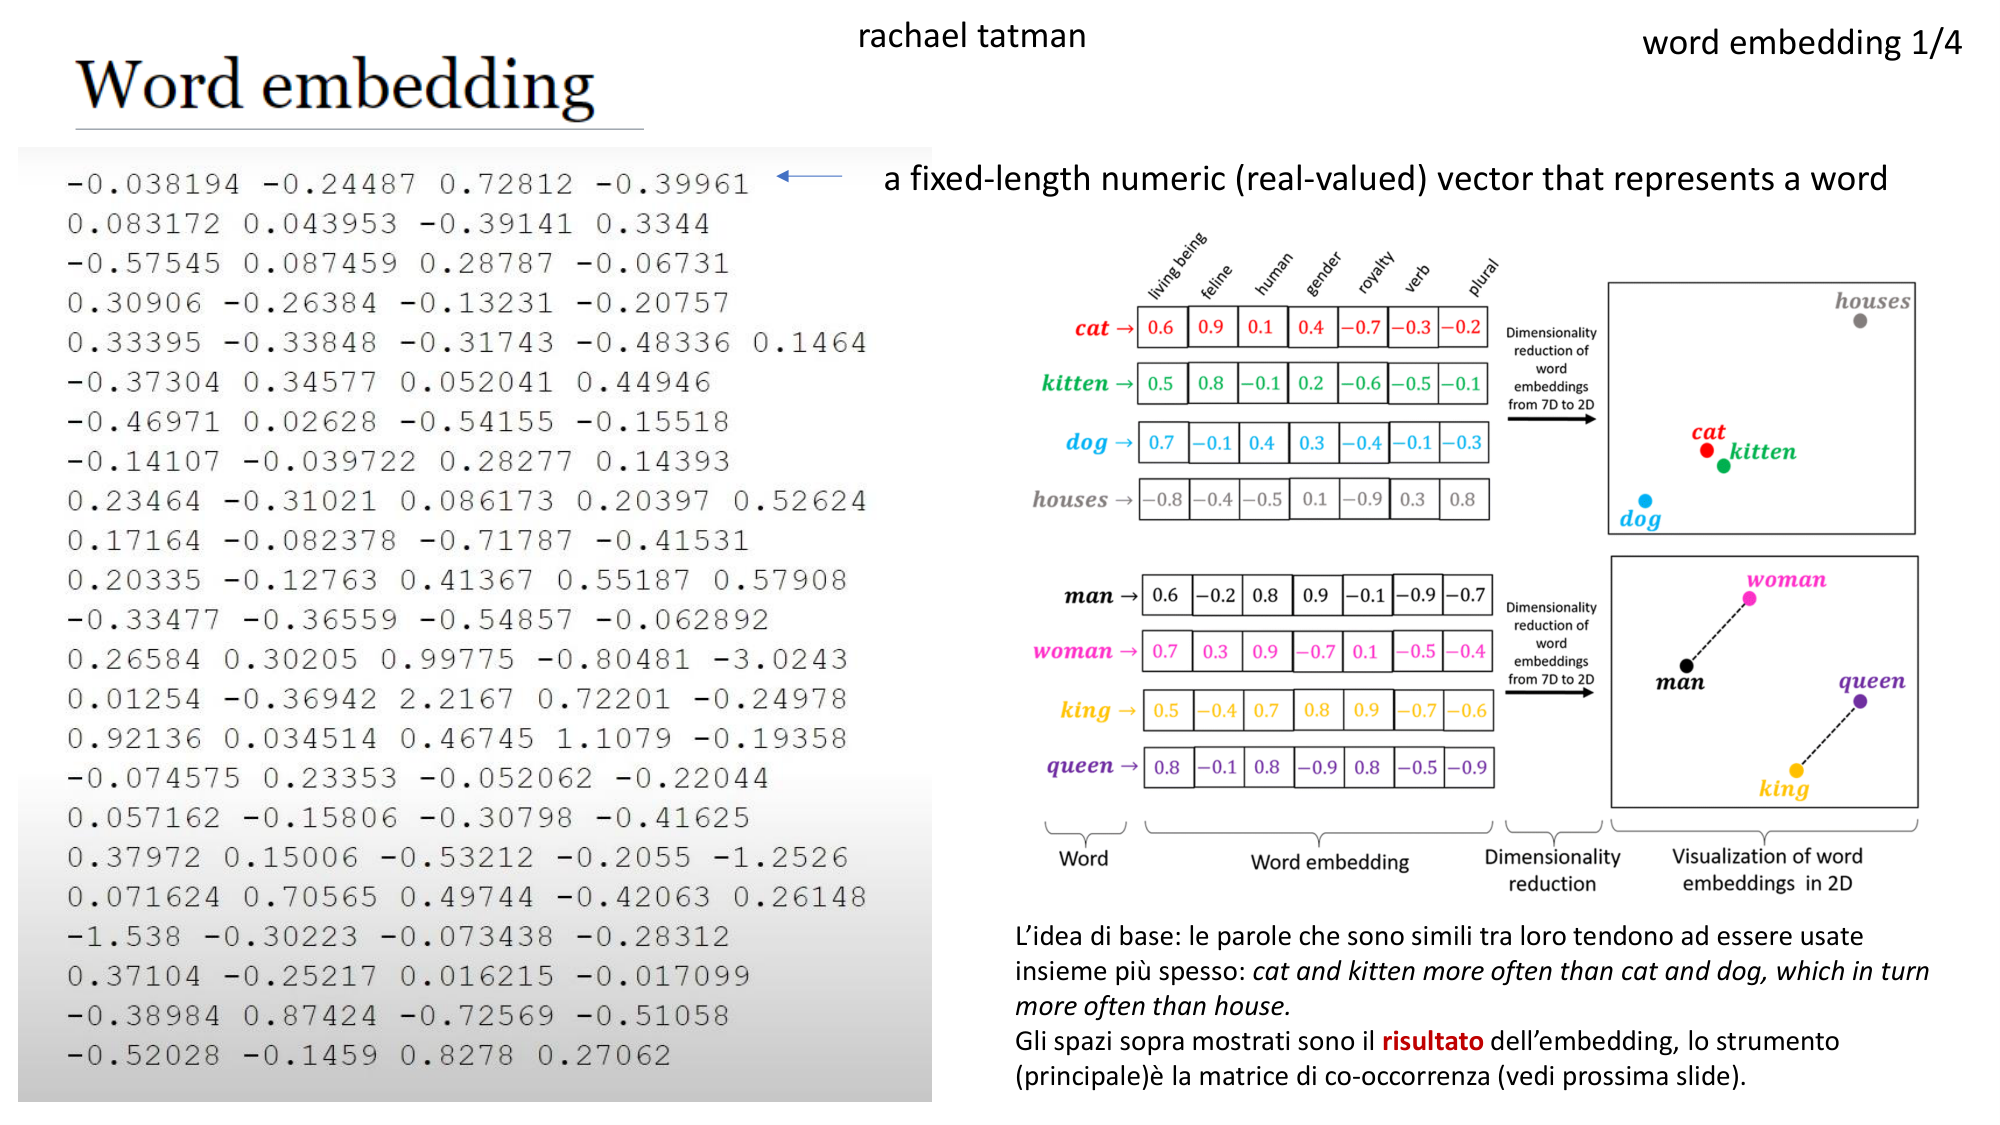

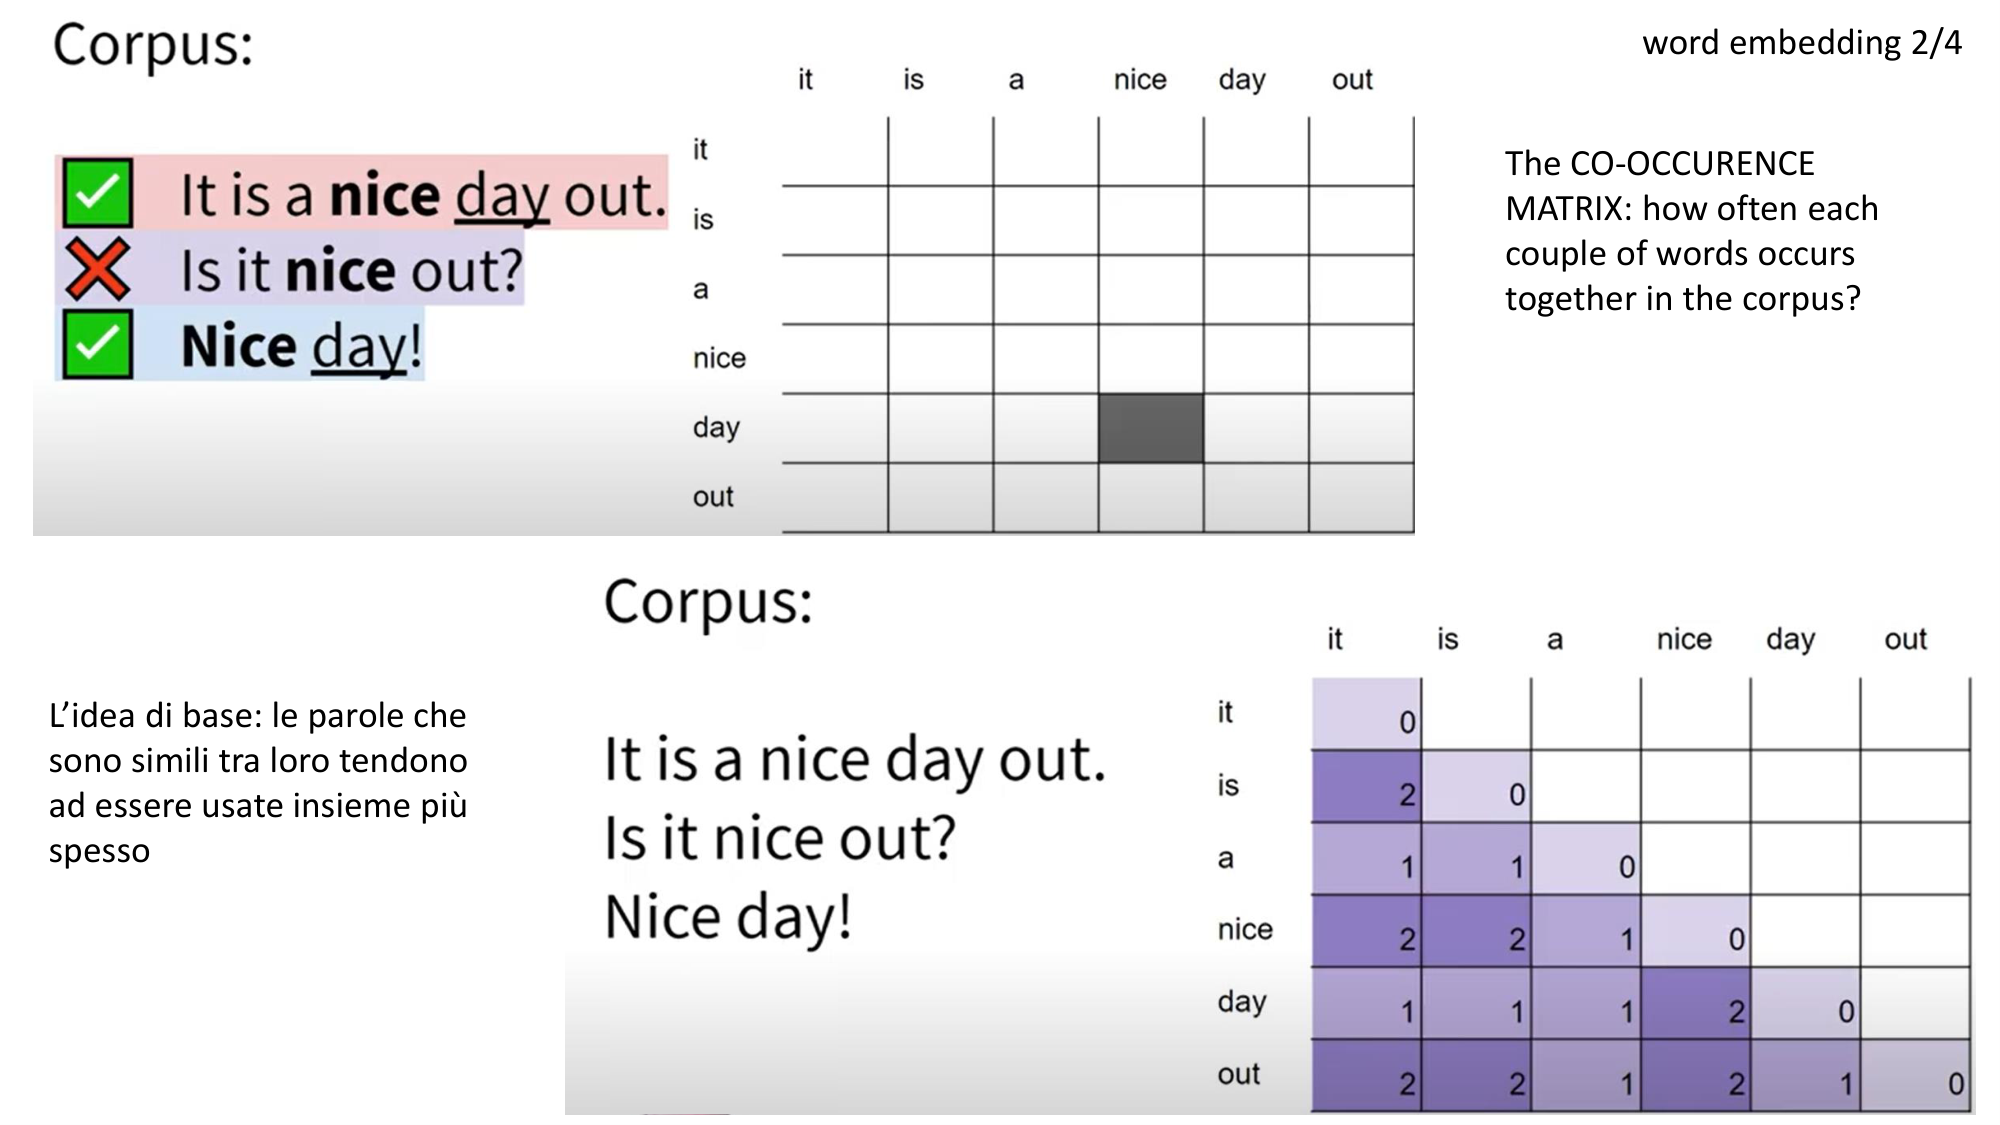

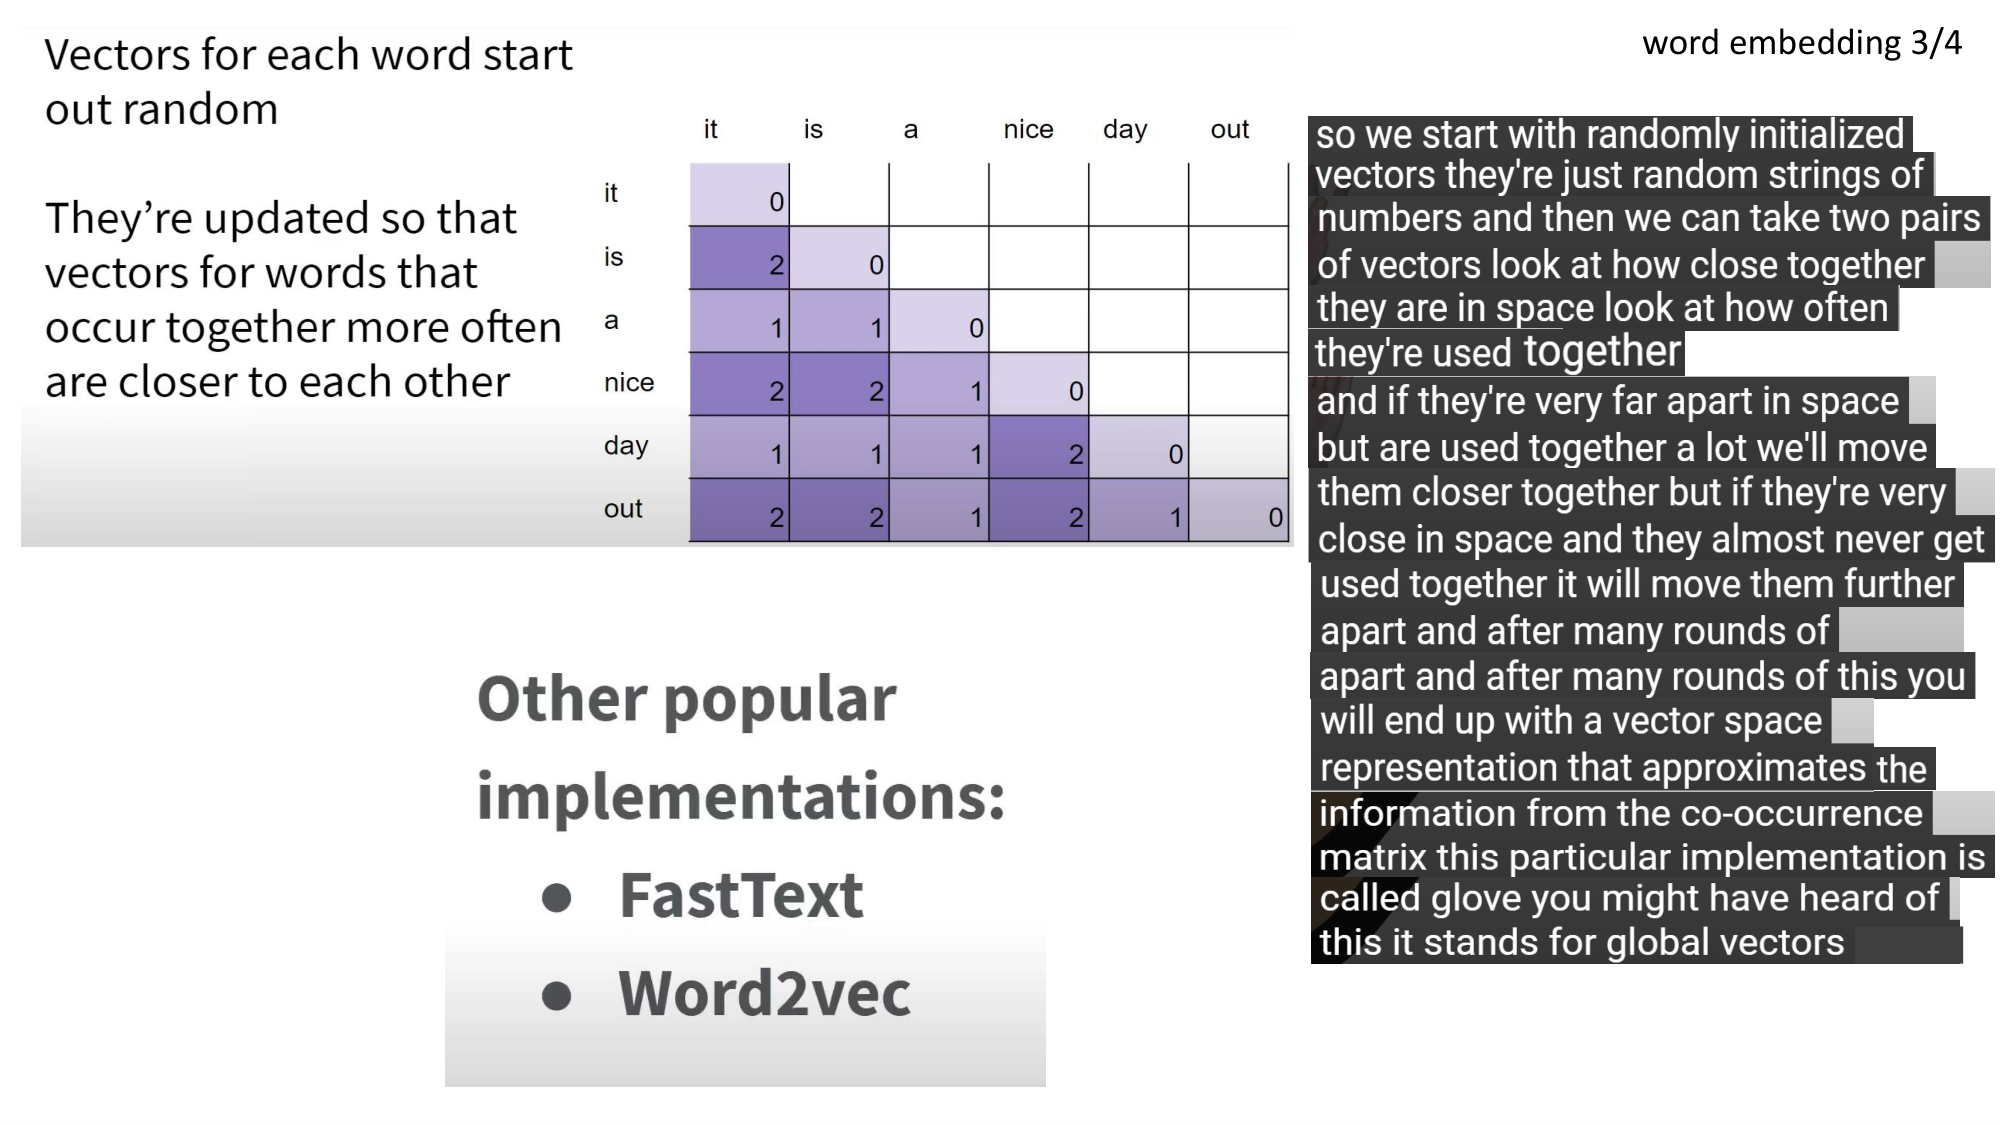

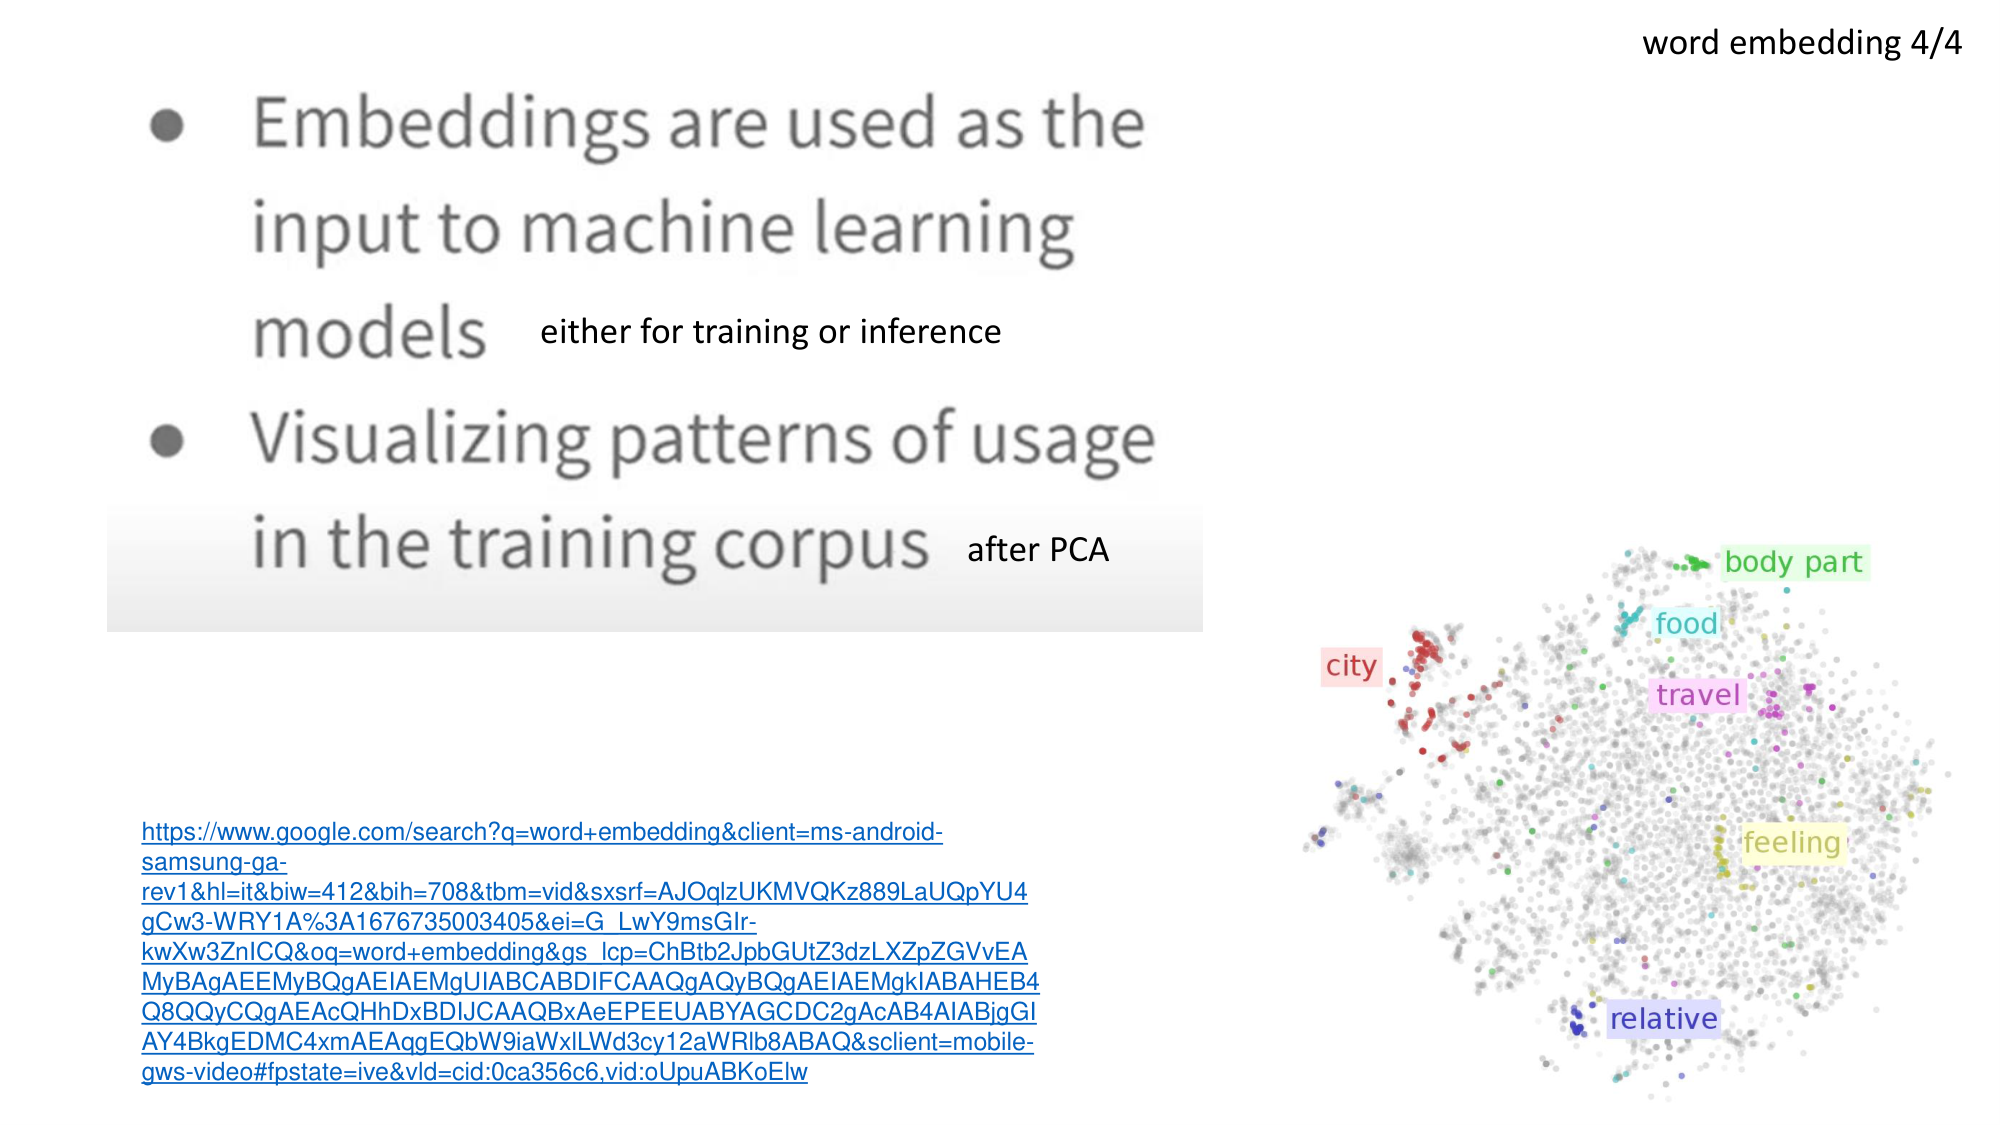

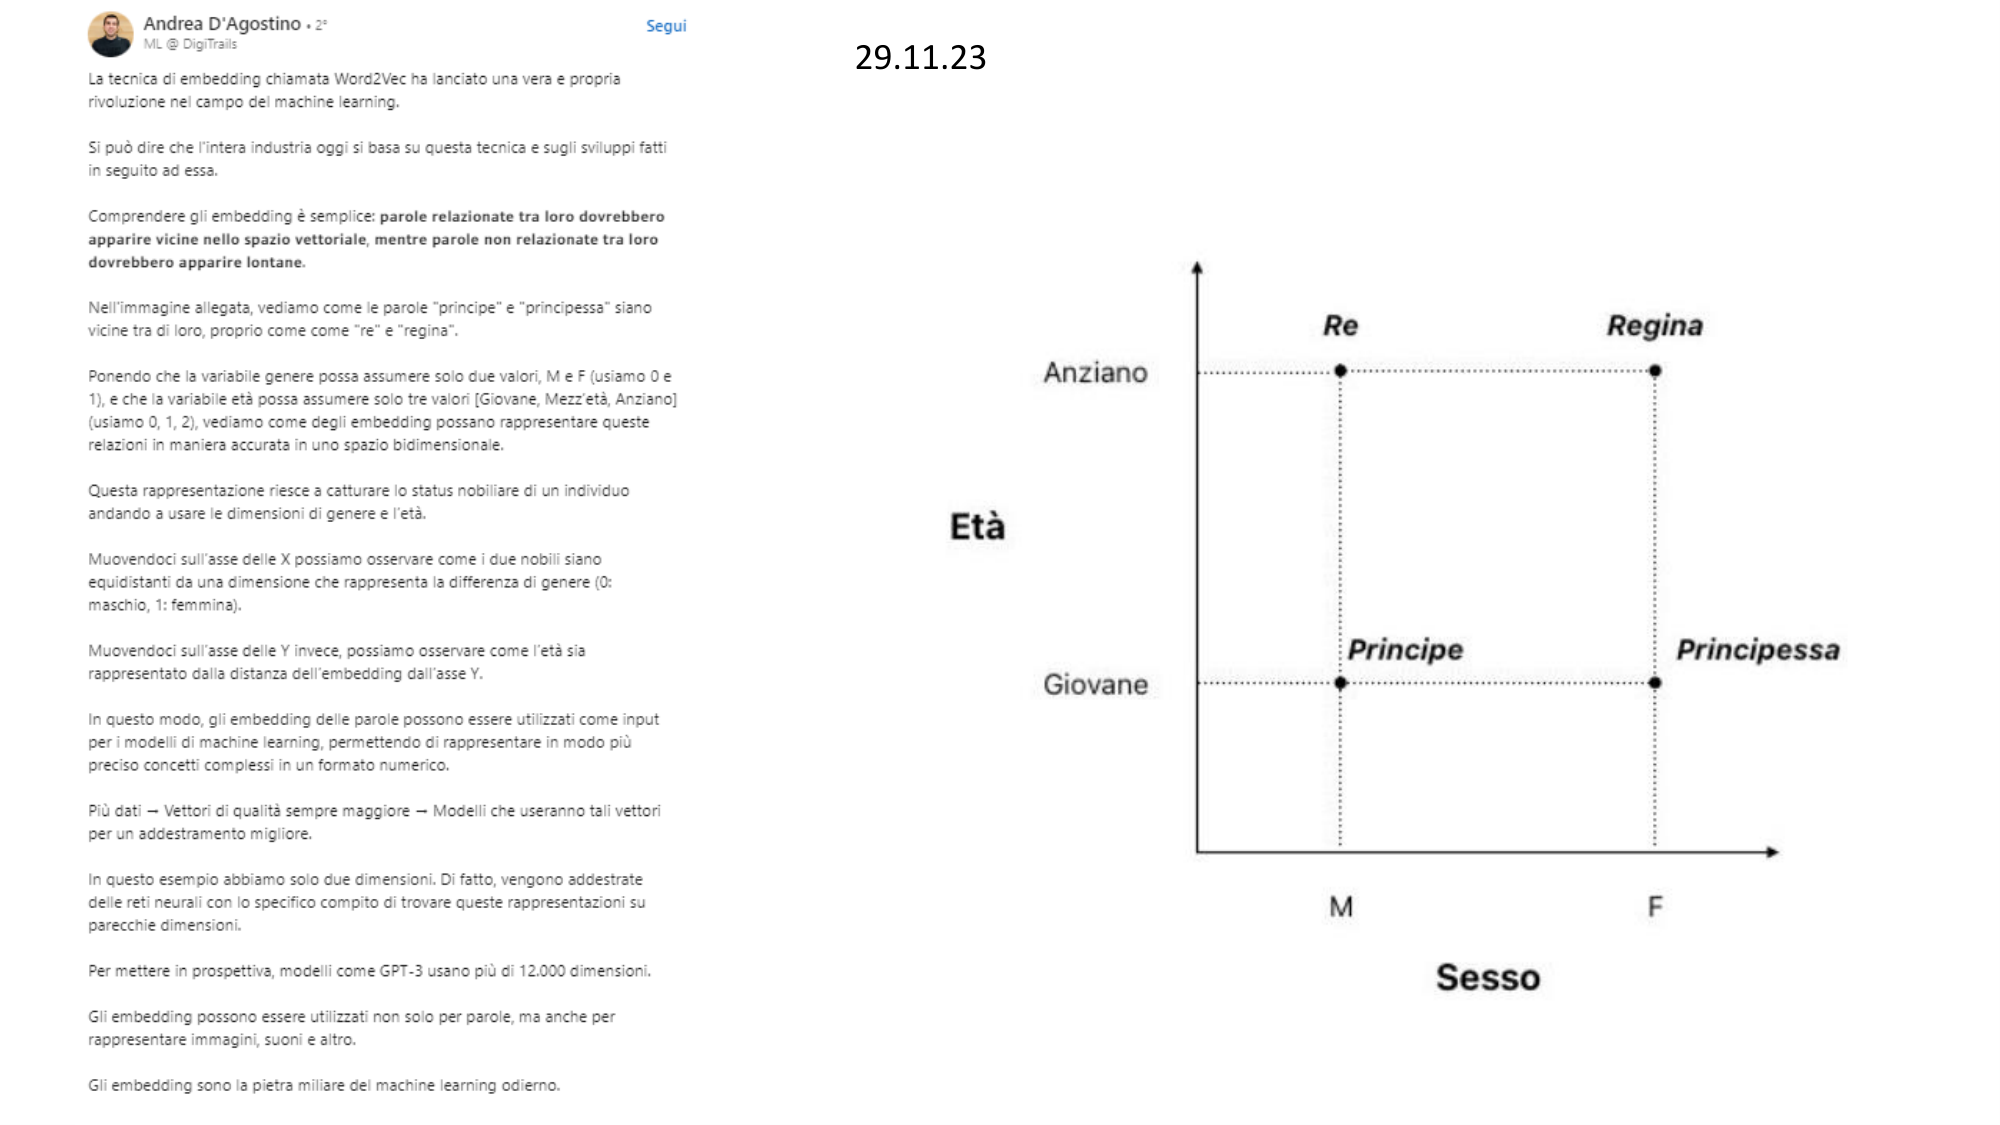

In [102]:
import pymupdf
from IPython.display import display, Image

doc = pymupdf.open("Word embedding.pdf")
for pagina in doc:
    pix = pagina.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png")))
doc.close()

# Codificare le posizioni delle parole

## Il limite dell'embedding

L'embedding dei token crea il corretto input per un LLM. C'è un problema, però: uno specifico token id **è mappato nello stesso identico vettore embedded a prescindere dalla sua posizione nella sequenza di input**. Si veda la seguente figura, nella quale il token ID 2 è presente 2 volte nell'input (*fox jumps over **fox***):

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/17.webp" width="800px">

La matrice risultante ha **due vettori embedding identici**.

## Gli embedding posizionali

Poichè anche il "meccanismo dell'attenzione" - che vedremo nel prossimo notebook - è anch'esso indipendente dalla posizione, è utile **inserire nel modello l'informazione AGGIUNTIVA della posizione** del token nella sequenza di input.

A questo scopo, possiamo utilizzare due tipologie di embedding *position-aware*, da aggiungere alla rappresentazione embedded originale:
* gli embedding posizionali **assoluti**
* gli embedding posizionali **relativi**

### Gli embedding posizionali assoluti

I primi (assoluti) sono **direttamente associati con la specifica posizione del token nella sequenza**. Cioè, per ogni posizione della sequenza in input, è generato un **embedding univoco**.<br>
La seguente figura, che illustra gli emebedding posizionali assoluti, si legge dal basso verso l'alto:
* nella riga in basso è rappresentata una sequenza di input che contiene <u>4 volte lo stesso token</u> (**già embedded in 3D**, per semplicità costituito da 3 valori 1); sono embedding *position-agnostic*
* nella riga intermedia sono rappresentati i corrispondenti **embedding posizionali** (assoluti, cioè univoci), da sommare (aggiungere) agli embedding **originali** della riga in basso; questi embedding (posizionali) devono avere la stessa dimensione (in questo caso 3) degli embedding originali
* la riga in alto riporta i token embedding *position-aware* finali; essi possono essere dati in input al training del modello (perchè incorporano l'informazione della posizione).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/18.webp" width="800px">

### Gli embedding posizonali relativi

Negli embedding posizionali **relativi**, invece, l'enfasi è sulla **distanza** tra token. Cioè, il modello impara dal training le relazioni tra token in termini di **"quanto sono separati"** anzichè "in quale esatta posizione sono". Il <u>vantaggio</u> degli embedding relativi è che il modello allenato saprà **generalizzare meglio a sequenze di lunghezza variabile**, anche se non ha mai visto tali sequenze durante l'allenamento.

Entrambe le soluzioni migliorano la capacità dei modelli di comprendere l'ordine e le relazioni tra token, garantendo previsioni (della prossima parola) accurate e consapevoli del contesto.

**I modelli GPT di OpenAI usano gli embedding posizionali <u>assoluti</u>**. Tuttavia essi sono ottimizzati durante il training, anzichè predefiniti come erano gli encoding posizionali nel modello transformer originale. Cioè **questa ottimizzazione è parte del processo di training complessivo**.

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — Dagli embedding posizionali assoluti a RoPE</b><br><br>
gpt-oss <b>abbandona del tutto</b> il layer di embedding posizionale appreso che abbiamo appena studiato: nel modello <u>non esiste più</u> una tabella <code>pos_emb</code> da sommare agli embedding dei token.<br><br>
Le posizioni entrano nel modello tramite <b>RoPE</b> (<i>Rotary Position Embeddings</i>, "embedding posizionali rotatori"): invece di <u>aggiungere</u> un vettore di posizione all'input, si <u>ruotano</u> — di un angolo che dipende dalla posizione del token — alcune rappresentazioni interne usate dal meccanismo dell'attenzione (i vettori <i>query</i> e <i>chiave</i>, che incontreremo nel prossimo notebook).<br><br>
Il risultato pratico: la similarità tra due token finisce per dipendere dalla loro <b>distanza relativa</b> — in questo RoPE è parente degli embedding posizionali <u>relativi</u> descritti sopra — e il modello generalizza meglio alle sequenze lunghe. È proprio su RoPE che agisce <b>YaRN</b>, la tecnica citata nell'innesto sulla finestra scorrevole, che porta il contesto di gpt-oss a 131.072 token.<br><br>
Implementeremo RoPE nel modulo dedicato a gpt-oss.
</div>

### Esperimenti realistici

La **dimensione dell'embedding** degli esempi precedenti era molto picccola (3) per semplicità. Ora consideriamo *embedding size* più realistiche ed utili, ad esempio **256**, che è molto più piccola di quella di GPT-3 (12.288) ma comunque ragionevole per delle sperimentazioni serie.

Assumiamo inoltre che il tokenizzatore sia **BPE** (esaminato nei precedenti capitoli), che una dimensione del vocabolario di **50.257**.

Istanziamo l'embedding layer con la solita funzione `torch.nn.Embedding`:

In [103]:
vocab_size = 50257    # la dimensione del vocabolario del BPE
output_dim = 256      # la dimensione della rappresentazione vettoriale

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>E in gpt-oss? — I numeri "realistici" diventano enormi</b><br><br>
Nei nostri esperimenti usiamo <code>vocab_size = 50257</code> e una dimensione di embedding di 256. In gpt-oss i valori reali sono <code>vocab_size = 201088</code> (il vocabolario di o200k_harmony) e una dimensione di embedding di <b>2.880</b>.<br><br>
La sola tabella di embedding dei token vale quindi 201.088 × 2.880 ≈ <b>579 milioni di parametri</b>. E poiché in gpt-oss la matrice che, all'<u>uscita</u> del modello, ritrasforma gli embedding in punteggi sul vocabolario (la incontreremo nel notebook 4) è una <u>seconda</u> tabella delle stesse dimensioni, non condivisa con la prima, tra ingresso e uscita si arriva a ≈ <b>1,16 miliardi di parametri</b>: più dell'<u>intero</u> modello GPT-2 da 124 milioni di parametri che costruiremo nei prossimi notebook!
</div>

Usiamo il `token_embedding_layer` istanziato adesso. Se campioniamo i dati dal DataLoader, embeddiamo ogni token di ogni batch in un vettore a 256 dimensioni.<br>
Immaginiamo di avere: *batch size = 8 righe (samples)*, ogni riga con 4 token (*input size = 4*). Se `output_dim` = 256 il risultato dell'embedding sarà un **tensore 3D di $8 x 4 x 256 = 8192$ elementi**.

Istanziamo il DataLoader visto al capitolo 6 (`create_dataloader_v1`) ed iteriamo sui batch (con un'istruzione differente dal precedente capitolo):

In [104]:
max_length = 4                        # input size
dataloader = create_dataloader_v1(
    raw_text,
    batch_size=8,
    max_length=max_length,            # per evitare l'overfitting
    stride=max_length,
    shuffle=False
)
data_iter = iter(dataloader)          # la consueta trasformazione del dataloader in un iteratore PyThon
inputs, targets = next(data_iter)     # l'iterazione sui batch (differente dal precedente capitolo: 'first batch = next(data_iter)'')

In [105]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [106]:
print("Token IDs:\n", targets)
print("\nInputs shape:\n", targets.shape)

Token IDs:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])

Inputs shape:
 torch.Size([8, 4])


Come si vede, i due tensori dei token ID hanno **dimensione $8x4$**, che **significa che il data batch campionato (dalla funzione `next`) consiste di 8 samples  di 4 token l'uno**. Attenzione: questi tensori NON sono ancora quelli embedded, ed infatti hanno dimensione $8x4$ e non $8x4x256$.

Ora facciamo l'embedding a 256 dimensioni dei tensori di input (istanziando l'embedding layer con la solita funzione `token_embedding_layer`).

In [107]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)   # --> ora 8x4x256

torch.Size([8, 4, 256])


Come si vede, ogni token ID è ora rappresentato (*embedded*) come **vettore (tensore) di 256 elementi**.

In [108]:
print(token_embeddings)

tensor([[[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
         [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],

        [[ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421],
         [-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091],
         [ 1.9847, -0.6483, -0.1415,  ..., -0.3841, -0.9355,  1.4478],
         [ 0.9647,  1.2974, -1.6207,  ...,  1.1463,  1.5797,  0.3969]],

        [[-0.7713,  0.6572,  0.1663,  ..., -0.8044,  0.0542,  0.7426],
         [ 0.8046,  0.5047,  1.2922,  ...,  1.4648,  0.4097,  0.3205],
         [ 0.0795, -1.7636,  0.5750,  ...,  2.1823,  1.8231, -0.3635],
         [ 0.4267, -0.0647,  0.5686,  ..., -0.5209,  1.3065,  0.8473]],

        ...,

        [[-1.6156,  0.9610, -2.6437,  ..., -0.9645,  1.0888,  1.6383],
         [-0.3985, -0.9235, -1.3163,  ..., -1.1582, -1.13

Come abbiamo detto GPT-2 usa l'embedding posizionale <u>assoluto</u>; dobbiamo quindi **creare un ulteriore layer di embedding** con la stessa dimensionalità del `token_embedding_layer`:

In [109]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
print(pos_embedding_layer.weight)   # i pesi dell'embedding layer

Parameter containing:
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       requires_grad=True)


In [110]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length)) #
print(pos_embeddings)

tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       grad_fn=<EmbeddingBackward0>)


L'input di `pos_embeddings` è solitamente un vettore segnaposto (*placeholder*) del tipo `torch.arange(context_length)`, che contiene **una sequenza di numeri 0, 1, ...**, fino alla lunghezza massima dell'input –1. La `context_length` è una variabile che rappresenta la dimensione di input supportata dall'LLM. Qui, la scegliamo **uguale alla lunghezza massima del testo di input** (aka, la *input size*). In pratica, il testo di input **può essere più lungo** della lunghezza di contesto supportata, nel qual caso dobbiamo **troncarlo**.

In [111]:
print(pos_embeddings.shape)

torch.Size([4, 256])


Come possiamo vedere, il tensore di embedding posizionale (assoluto) è costituito da **quattro vettori a 256 dimensioni**. Ora possiamo aggiungerli direttamente agli embedding dei token: PyTorch **aggiungerà** il tensore `pos_embeddings` di dimensione $4 × 256$ a ciascun tensore di embedded token (anch'essi di dimensione $4 × 256$), in **ciascuno degli otto batch**:

In [112]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)
print(input_embeddings)

torch.Size([8, 4, 256])
tensor([[[ 2.2288,  0.5619,  0.8286,  ..., -0.6272, -0.2987,  0.8900],
         [ 2.0903, -0.4664, -0.0593,  ...,  0.9115, -1.0493, -1.6473],
         [-0.7158, -0.8304,  1.2494,  ...,  2.3952,  1.8773,  0.8051],
         [ 0.2703,  0.4029,  3.0514,  ...,  0.3595, -1.4548,  0.8310]],

        [[ 3.2835,  1.1749, -1.4150,  ..., -0.3281,  2.4332,  0.6924],
         [-0.2199, -0.9114, -0.1750,  ...,  1.5337, -0.1998,  0.1462],
         [ 1.5197, -1.4240,  0.4391,  ...,  1.0494, -1.4318,  2.3057],
         [ 0.2893,  0.8346, -0.1884,  ...,  1.9602,  0.8709,  0.8796]],

        [[ 0.9662,  0.0952, -0.4640,  ..., -1.0320,  1.6290,  1.7771],
         [ 2.4468, -0.2154,  1.4984,  ...,  1.8766,  0.5595, -0.1423],
         [-0.3856, -2.5393,  1.1556,  ...,  3.6157,  1.3267,  0.4944],
         [-0.2487, -0.5275,  2.0009,  ...,  0.2930,  0.5977,  1.3300]],

        ...,

        [[ 0.1219,  0.3991, -3.2740,  ..., -1.1921,  2.6637,  2.6728],
         [ 1.2438, -1.6436, -1.11

Nella seguente figura è riassunto il processo completo di pre-processing dei dati che abbiamo svolto in questo notebook. Abbiamo prodotto il tensore 3D `input_embeddings`, che costituirà l'input all'allenamento dell'LLM.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/19.webp" width="600px">

# Sintesi e messaggi *takeaway*

* Gli LLM richiedono che i dati testuali siano convertiti in **vettori numerici, noti come embedding**, poiché essi (gli LLM) non possono elaborare testo grezzo. Gli embedding **trasformano dati discreti (come parole o immagini) in spazi vettoriali continui**, rendendoli compatibili con le operazioni delle reti neurali.<br><br>
* Come primo step, il testo grezzo è **suddiviso in token**, che possono essere **parole o caratteri**. Successivamente, i token sono convertiti in **rappresentazioni numeriche intere, denominate ID token**.<br><br>
* È possibile aggiungere **token speciali**, come <|unk|> e <|endoftext|>, per migliorare la comprensione del modello e gestire diversi contesti, come **parole sconosciute** o per delimitare il **confine tra testi non correlati**.<br><br>
* Il **tokenizzatore BPE** (Byte Pair Encoding), che è utilizzato per LLM come GPT-2 e GPT-3, può gestire efficacemente le parole sconosciute, suddividendole in sottoparole o singoli caratteri.<br><br>
* In questo corso utilizziamo un **approccio a finestra scorrevole** (sliding windows approach) sui dati tokenizzati, per generare **coppie input-target** per l'addestramento degli LLM.<br><br>
* I **livelli di embedding** ("incorporamento") in PyTorch funzionano come un'operazione di ricerca su una tabella (**lookup**), recuperando dalla tabella vettori corrispondenti agli ID dei token. I vettori di incorporamento risultanti forniscono **rappresentazioni continue dei token**, il che è fondamentale per l'addestramento di modelli di deep learning come gli LLM.<br><br>
* Sebbene gli incorporamenti dei token forniscano rappresentazioni vettoriali coerenti per ciascun token, sono **position-agnostic**, cioè non forniscono un'idea precisa della posizione del token in una sequenza. Per ovviare a questo problema, esistono due tipi principali di **incorporamenti posizionali: assoluti e relativi**. I modelli GPT di OpenAI utilizzano gli incorporamenti posizionali **assoluti**, che sono aggiunti ai vettori di incorporamento dei token e **ottimizzati durante l'addestramento del modello**.

<div style="background-color:#eaf3ff; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px">
🧩 <b>Riepilogo degli innesti — da GPT-2 a gpt-oss (capitolo 2)</b><br><br>
<table style="border-collapse:collapse">
<tr><th style="border:1px solid #9bb8d3; padding:6px 10px; background:#d6e8fb; text-align:left">Aspetto</th><th style="border:1px solid #9bb8d3; padding:6px 10px; background:#d6e8fb; text-align:left">GPT-2 (questo corso)</th><th style="border:1px solid #9bb8d3; padding:6px 10px; background:#d6e8fb; text-align:left">gpt-oss</th></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Tokenizzatore</td><td style="border:1px solid #9bb8d3; padding:6px 10px">BPE "gpt2", 50.257 voci</td><td style="border:1px solid #9bb8d3; padding:6px 10px">BPE "o200k_harmony", 201.088 voci (sempre via <code>tiktoken</code>)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Token speciali</td><td style="border:1px solid #9bb8d3; padding:6px 10px"><code>&lt;|endoftext|&gt;</code> (ID 50256)</td><td style="border:1px solid #9bb8d3; padding:6px 10px"><code>&lt;|endoftext|&gt;</code> (ID 199999) + token del formato Harmony (<code>&lt;|start|&gt;</code>, <code>&lt;|message|&gt;</code>, <code>&lt;|channel|&gt;</code>, …)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Coppie input-target (finestra scorrevole)</td><td style="border:1px solid #9bb8d3; padding:6px 10px">schema di questo capitolo</td><td style="border:1px solid #9bb8d3; padding:6px 10px">identico</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Embedding posizionali</td><td style="border:1px solid #9bb8d3; padding:6px 10px">assoluti, appresi (tabella da sommare)</td><td style="border:1px solid #9bb8d3; padding:6px 10px">nessuna tabella: RoPE dentro l'attenzione</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Context length</td><td style="border:1px solid #9bb8d3; padding:6px 10px">1.024 token</td><td style="border:1px solid #9bb8d3; padding:6px 10px">131.072 token (via YaRN)</td></tr>
<tr><td style="border:1px solid #9bb8d3; padding:6px 10px">Dimensione di embedding</td><td style="border:1px solid #9bb8d3; padding:6px 10px">768 (GPT-2 124M)</td><td style="border:1px solid #9bb8d3; padding:6px 10px">2.880</td></tr>
</table>
<br>
Il confronto completo, con l'implementazione dei nuovi componenti, è sviluppato nel <b>modulo dedicato a gpt-oss</b> (notebook 8, <i>"Da GPT-2 a gpt-oss"</i>).
</div>